In this file I want to run the CG algorithm and the FBP algorithm on the phantom to see how it works out. Additionally, trials with regularization will be done.

## Installing packages and setting defaults

In [1]:
# retrieving needed packages

# cil imports
from cil.framework import ImageData, ImageGeometry
from cil.framework import AcquisitionGeometry, AcquisitionData

from cil.processors import Slicer, AbsorptionTransmissionConverter, TransmissionAbsorptionConverter

from cil.optimisation.functions import IndicatorBox
from cil.optimisation.algorithms import CGLS, SIRT
from cil.optimisation.utilities import callbacks

from cil.plugins.astra.operators import ProjectionOperator
from cil.plugins.astra.processors import FBP
from cil.optimisation.algorithms import FISTA

from cil.plugins.ccpi_regularisation.functions import FGP_TV


#from cil.plugins import TomoPhantom
from phantominator import shepp_logan


from cil.utilities import dataexample
from cil.utilities.display import show2D, show1D, show_geometry

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging


from cil.optimisation.functions import IndicatorBox, MixedL21Norm, L2NormSquared, \
                                       BlockFunction, L1Norm, LeastSquares, \
                                       OperatorCompositionFunction, TotalVariation 

from cil.optimisation.algorithms import GD, FISTA, PDHG

from cil.optimisation.operators import BlockOperator, GradientOperator,\
                                       GradientOperator, IdentityOperator

In [2]:
# Set logging level for CIL processors:
logging.basicConfig(level=logging.WARNING)
cil_log_level = logging.getLogger('cil.processors')
cil_log_level.setLevel(logging.INFO)

In [3]:
# Setting background defaults

cmap = "rainbow"
device = "cpu"

## Setting up problem and adding noise

In [4]:
def get_A(n_angles, n_pixels):

    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # Setup acquisition geometry

    # Note that if number of pixels and number of angels are equal, 
    # the matrix is square and an exact solution can be found, 
    # then there is a sufficient number of pojections
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    A = ProjectionOperator(ig, ag, device)

    # Get phantom
    phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

    # Create an acquisition data (numerically)
    sino = A.direct(phantom)

    return A, sino, ig, ag, phantom

def get_fbp(n_angles, n_pixels):

    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # Setup acquisition geometry

    # Note that if number of pixels and number of angels are equal, 
    # the matrix is square and an exact solution can be found, 
    # then there is a sufficient number of pojections
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    A = ProjectionOperator(ig, ag, device)

    # Get phantom
    phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

    # Create an acquisition data (numerically)
    sino = A.direct(phantom)

    fbp = FBP(ig, ag, device)
    print(n_angles, n_pixels)

    return fbp, sino

In [5]:
# number of pixels and number of angles
n_pixels = 256
n_angles = 50

A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


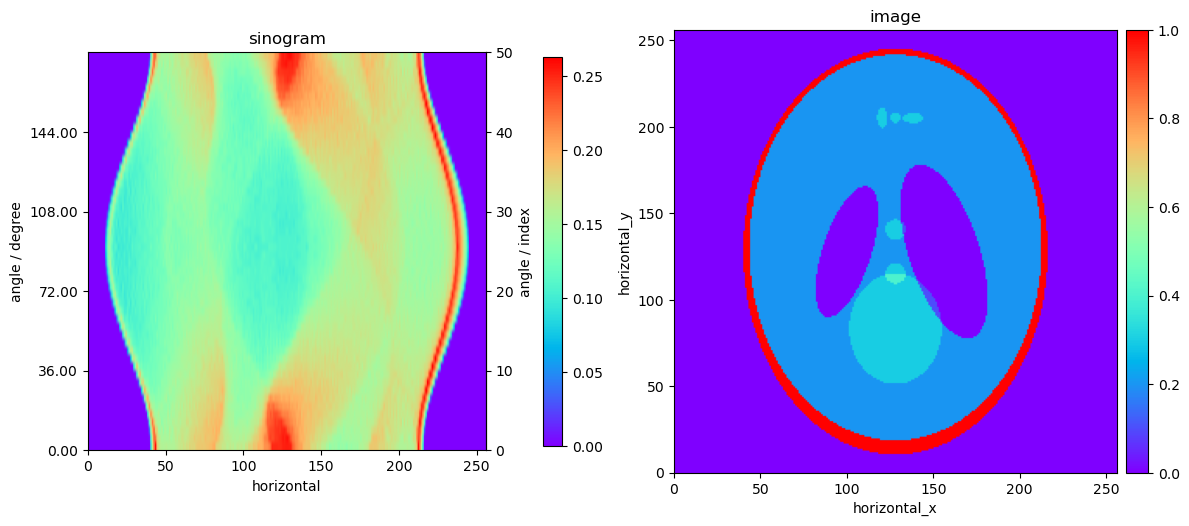

In [6]:
# Show the picture of the example that will be worked with in this code

# Create projection operator using Astra-Toolbox.
A = ProjectionOperator(ig, ag, device)

# Create an acquisition data (numerically)
sino = A.direct(phantom)

show2D([sino, phantom], ['sinogram', 'image'], cmap=cmap, size=(12,6))

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


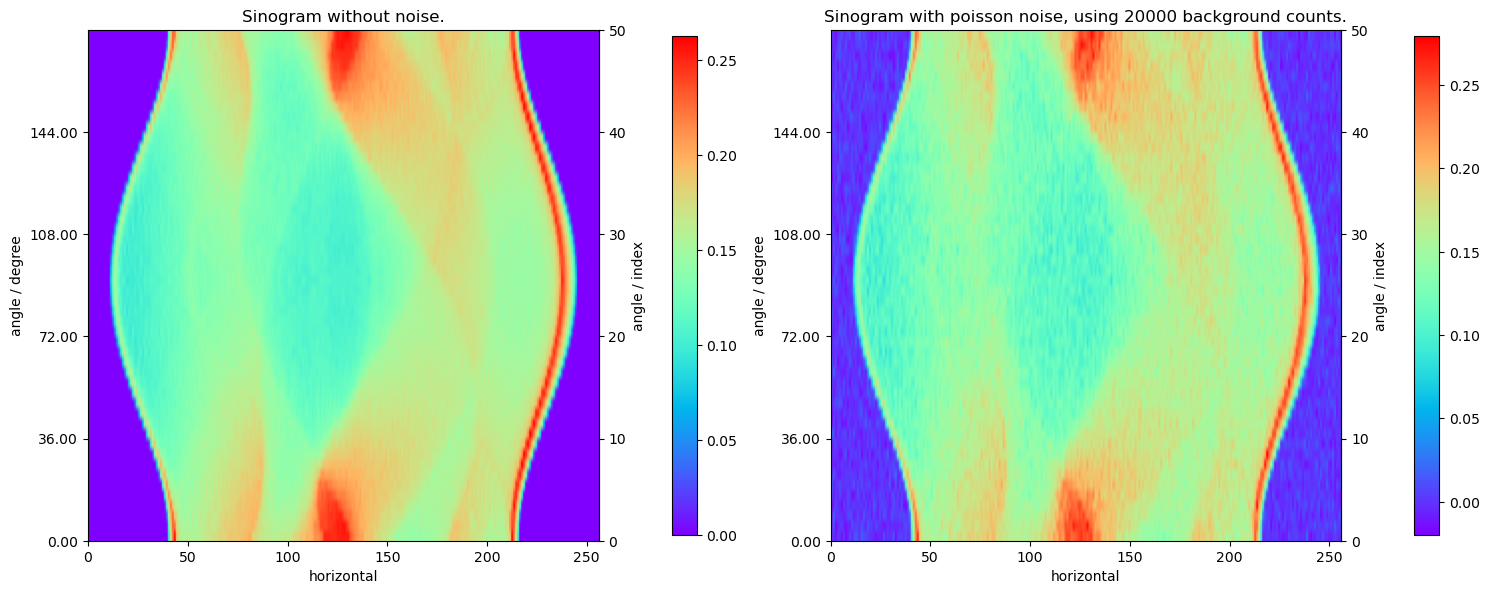

In [7]:
# Incident intensity: lower counts will increase the noise
def add_poss_noise(background_counts, n_angles, n_pixels):

    A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

    # adding noise to the sinogram

    # Convert the simulated absorption sinogram to transmission values using Lambert-Beer. 
    counts_poss = background_counts * np.exp(-sino.as_array())

    # Use as a mean for Poisson data generation.
    noisy_counts_poss = np.random.poisson(counts_poss)
    nonzero = noisy_counts_poss > 0

    # Convert back to absorption sinogram.
    sino_out_poss = np.zeros_like(sino.as_array())
    sino_out_poss[nonzero] = -np.log(noisy_counts_poss[nonzero]/ background_counts)

    # allocate sino_noisy and fill with noisy data
    sino_noisy_poss = ag.allocate()
    sino_noisy_poss.fill(sino_out_poss)

    return sino_noisy_poss

sino_noise = add_poss_noise(20000, n_angles, n_pixels)
show2D([sino, sino_noise], 
       ['Sinogram without noise.', 'Sinogram with poisson noise, using 20000 background counts.'], 
       cmap=cmap)


## Comparing FBP

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


50 265
280 265
running sino_noise_more, poisson noise with 280 angles and 265 pixels 0.11696124076843262


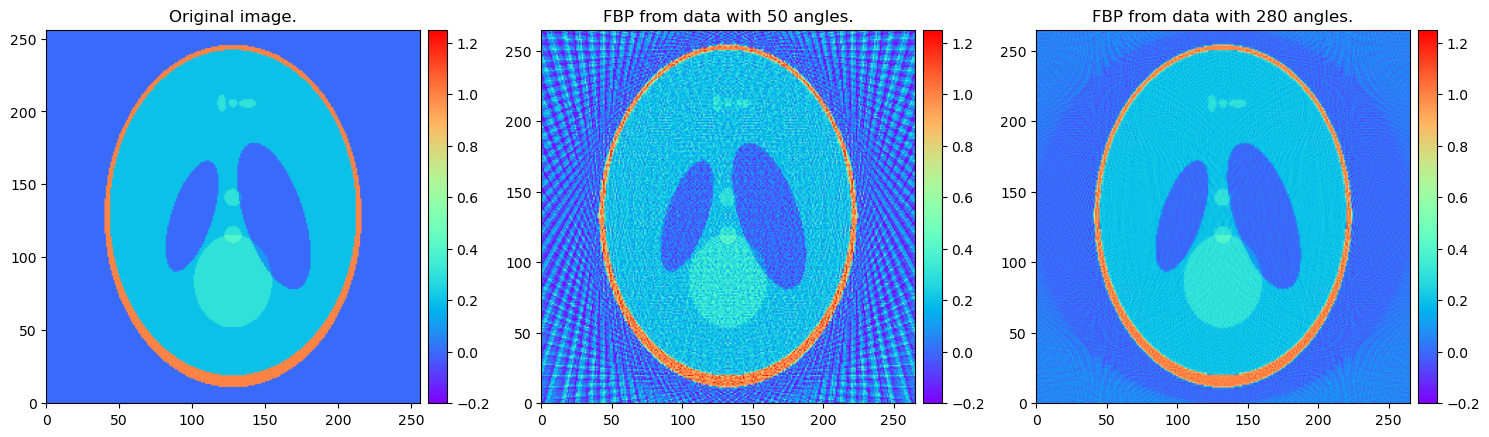

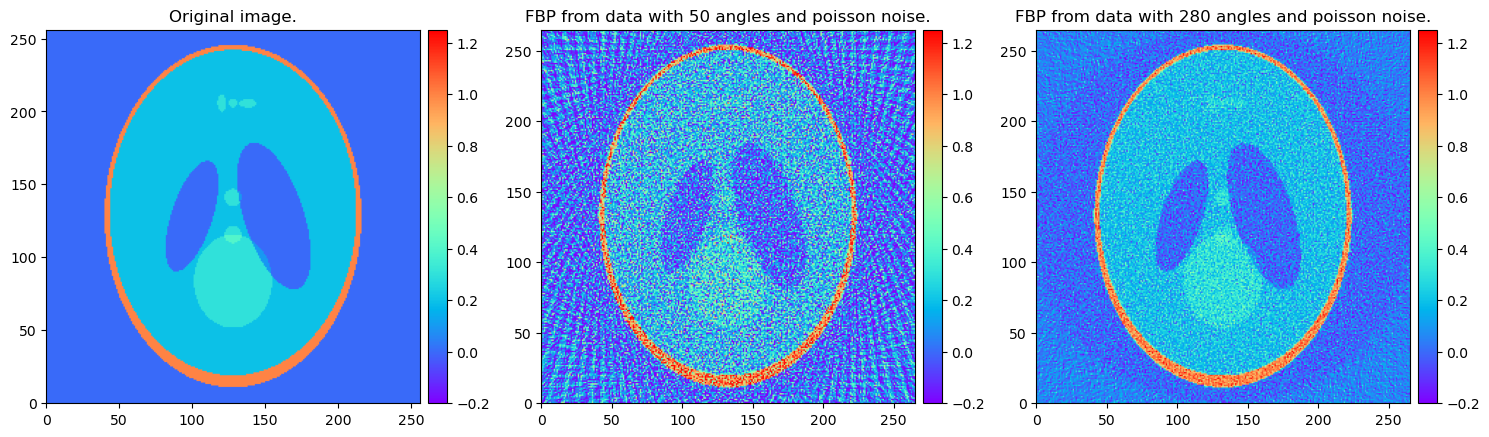

In [8]:
import time

fbp_less, sino_less = get_fbp(50, 265)
fbp_more, sino_more = get_fbp(280, 265)
sino_noise = add_poss_noise(20000, 50, 265)

t0 = time.time()
sino_noise_more = add_poss_noise(20000, 280, 265)
t1 = time.time()

print("running sino_noise_more, poisson noise with 280 angles and 265 pixels", t1- t0)

recon_less = fbp_less(sino_less)
recon_more = fbp_more(sino_more)
recon_noise = fbp_less(sino_noise)
recon_noise_more = fbp_more(sino_noise_more)

show2D([phantom, recon_less, recon_more], ['Original image.', 'FBP from data with 50 angles.', 'FBP from data with 280 angles.'], 
       cmap=cmap, fix_range=(-0.2, 1.25), 
       num_cols = 3, 
       axis_labels=('',''))

show2D([phantom, recon_noise, recon_noise_more],['Original image.', 'FBP from data with 50 angles and poisson noise.', 'FBP from data with 280 angles and poisson noise.'], 
       cmap=cmap, fix_range=(-0.2, 1.25), 
       num_cols = 3, 
       axis_labels=('','')) 

## Solving via Least Squares

In [9]:
# setting up data fidelity term and starting point
A, sino, ig, ag, phantom = get_A(n_angles=50, n_pixels=265)
sino_noise = add_poss_noise(20000, 50, 265)

f1 = LeastSquares(A, sino, (1/2))
f1_poss = LeastSquares(A, sino_noise, (1/2))

x0 = ig.allocate(0.0)

In [10]:
# no regularisation, no noise with GD

myGD_LS = GD(initial=x0, 
             f=f1, 
             step_size=None, 
             update_objective_interval=10)

myGD_LS.run(300, verbose=1)
myGD_LS_reco = myGD_LS.solution

  0%|          | 0/300 [00:00<?, ?it/s]

In [11]:
# no regularisation, poisson noise with GD
import time


myGD_LS_poss = GD(initial=x0, 
             f=f1_poss, 
             step_size=None, 
             update_objective_interval=10)

t0 = time.time()
myGD_LS_poss.run(300, verbose=1)
t1 = time.time()

print("time", t1 - t0)
myGD_LS_poss_reco = myGD_LS_poss.solution

  0%|          | 0/300 [00:00<?, ?it/s]

time 41.81970524787903


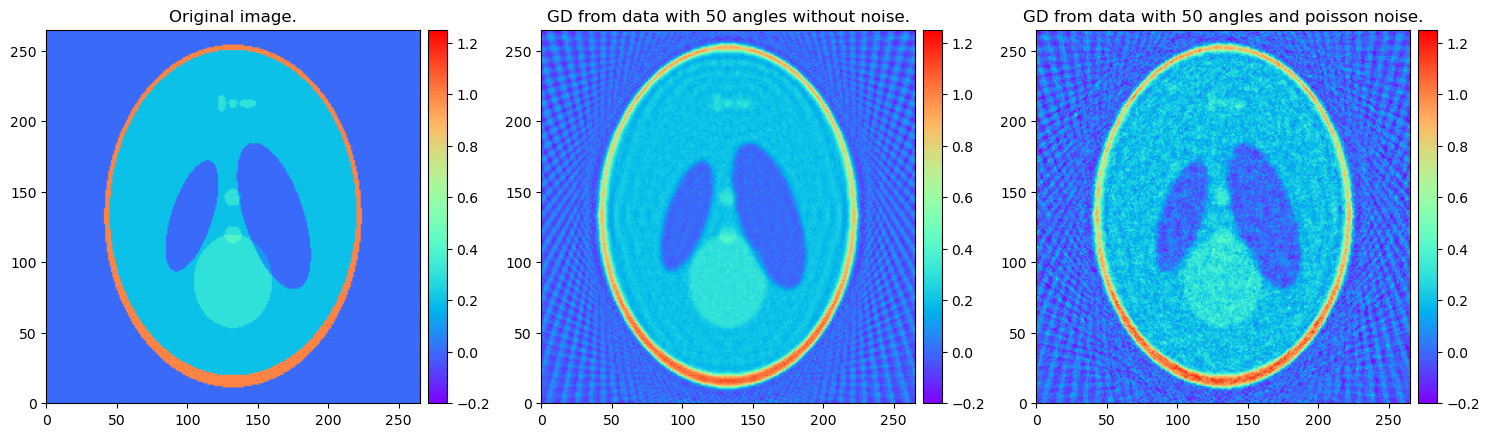

In [12]:
show2D([phantom, myGD_LS_reco, myGD_LS_poss_reco],['Original image.', 'GD from data with 50 angles without noise.', 'GD from data with 50 angles and poisson noise.'], 
       cmap=cmap, fix_range=(-0.2, 1.25), 
       num_cols = 3, 
       axis_labels=('','')) 

## Adding in regularization

Now we solve a least squares problem with Tikhonov regularization, that is the minimization problem becomes
\begin{equation}
\min_{u}\|Au - b\|_2^2 + \alpha^2 \|u\|_2^2
\end{equation}
In here, alpha$ is the regularization parameter.

In [ ]:
A, sino, ig, ag, phantom = get_A(n_angles=50, n_pixels=265)
sino_noise = add_poss_noise(20000, 50, 265)
alpha1 = 2e-3
alpha2 = 1e-2

f2 = L2NormSquared()
f_ridge1 = f1_poss + alpha1*f2
f_ridge2 = f1_poss + alpha2*f2

myGD_LS_ridge1 = GD(initial=x0, 
            f=f_ridge1, 
            step_size=1/f_ridge1.L,    # does not run without this stepsize  
            update_objective_interval=10)

myGD_LS_ridge1.run(300, verbose=1)
myGD_LS_ridge1_sol = myGD_LS_ridge1.solution

myGD_LS_ridge2 = GD(initial=x0, 
            f=f_ridge2, 
            step_size=1/f_ridge2.L,    # does not run without this stepsize  
            update_objective_interval=10)

myGD_LS_ridge2.run(300, verbose=1)
myGD_LS_ridge2_sol = myGD_LS_ridge2.solution

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

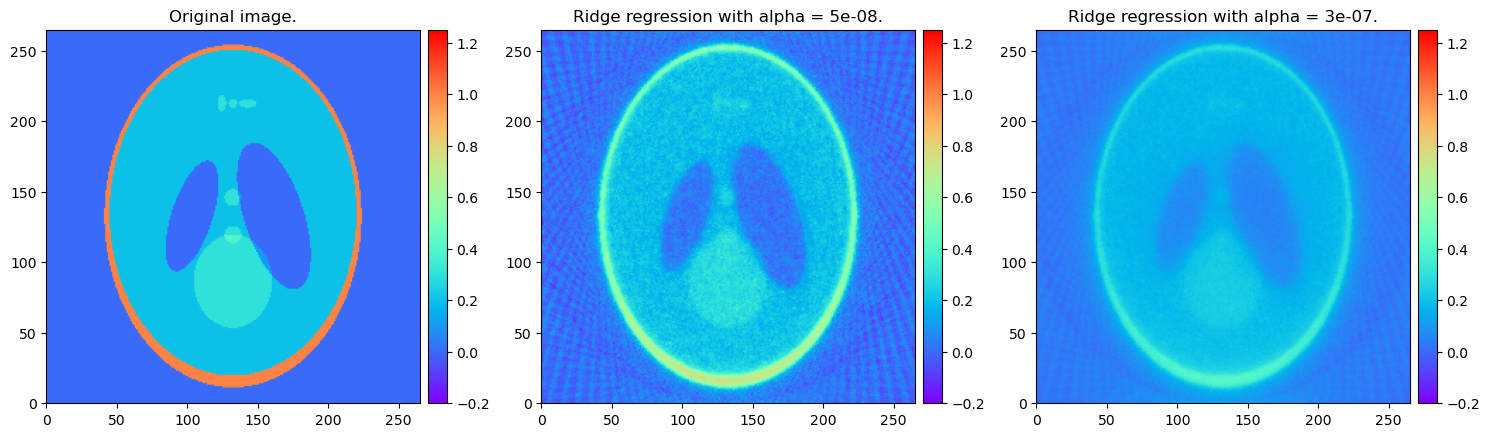

In [22]:
show2D([phantom, myGD_LS_ridge1_sol, myGD_LS_ridge2_sol],['Original image.', f'Ridge regression with alpha = {alpha1}.', f'Ridge regression with alpha = {alpha2}.'], 
       cmap=cmap, fix_range=(-0.2, 1.25), 
       num_cols = 3, 
       axis_labels=('','')) 

Now we solve a least squares problem with Tikhonov regularization, that is the minimization problem becomes
\begin{equation}
\min_{u}\|Au - b\|_2^2 + \alpha^2 \|Du\|_2^2
\end{equation}
In here $D$ is the gradient operator $\triangledown$ and $\alpha$ is the regularization parameter.

In [17]:
A, sino, ig, ag, phantom = get_A(n_angles=50, n_pixels=265)
sino_noise = add_poss_noise(20000, 50, 265)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


In [18]:
# setting tikhonov regularisation term
D = GradientOperator(ig)

f2_sridge = OperatorCompositionFunction(L2NormSquared(),D)

In [26]:
# trying some different values for alpha
alpha1 = 5e-8
alpha2 = 3e-7

f_sridge1 = f1_poss + (alpha1)*f2_sridge
f_sridge2 = f1_poss + (alpha2)*f2_sridge

myGD_LS_sridge1 = GD(initial=x0, 
            f=f_sridge1, 
            step_size=1/f_sridge1.L,    # does not run without this stepsize  
            update_objective_interval=10)

myGD_LS_sridge2 = GD(initial=x0, 
            f=f_sridge2, 
            step_size=1/f_sridge2.L,    # does not run without this stepsize  
            update_objective_interval=10)


myGD_LS_sridge1.run(300, verbose=1)
myGD_LS_sridge1_reco = myGD_LS_sridge1.solution

myGD_LS_sridge2.run(300, verbose=1)
myGD_LS_sridge2_reco = myGD_LS_sridge2.solution

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

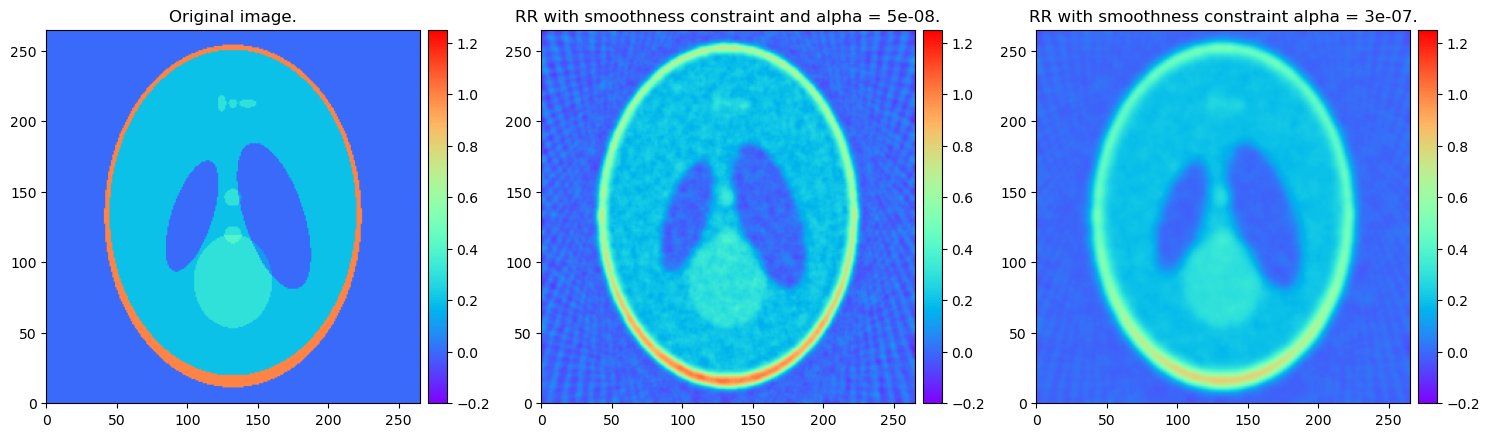

In [28]:
show2D([phantom, myGD_LS_sridge1_reco, myGD_LS_sridge2_reco], 
           ['Original image.', f'RR with smoothness constraint and alpha = {alpha1}.', f'RR with smoothness constraint alpha = {alpha2}.'],
            cmap=cmap,  
           num_cols = 3, 
           fix_range=(-0.2, 1.25), 
           axis_labels=('', ''))

## Total variation regularization

For this we need to run with FISTA. To compare equally, we run the other programmes with FISTA as well

In [53]:
# I dont think I understand it, but can try

alpha1 = 1e-4
alpha2 = 5e-4
G = IndicatorBox(lower=0.0)

TV1 = FGP_TV(alpha=alpha1, nonnegativity=True, device='cpu')
fista_TV1 = FISTA(initial=x0, f=f1_poss, g=TV1, update_objective_interval=10)


t1 = time.time()
fista_TV1.run(100)
t2 = time.time()
print("time", t2 - t1)

TV_reco1 = fista_TV1.solution


TV2 = FGP_TV(alpha=alpha2, nonnegativity=True, device='cpu')
fista_TV2 = FISTA(initial=x0, f=f1_poss, g=TV2, update_objective_interval=10)

fista_TV2.run(100)
TV_reco2 = fista_TV2.solution

  0%|          | 0/100 [00:00<?, ?it/s]

time 18.17271113395691


  0%|          | 0/100 [00:00<?, ?it/s]

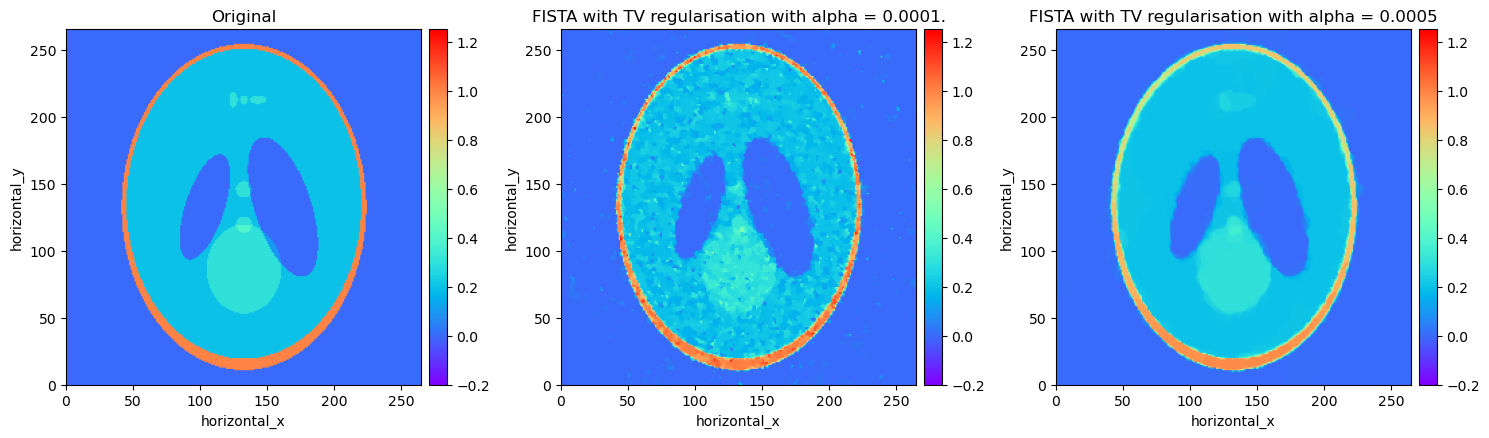

In [54]:
show2D([phantom, TV_reco1, TV_reco2], 
       ['Original', f'FISTA with TV regularisation with alpha = {alpha1}.', f'FISTA with TV regularisation with alpha = {alpha2}'], 
       num_cols = 3, 
       cmap=cmap, 
       fix_range=(-0.2, 1.25))